# Fase 1: ganadores por categoría y señal de popularidad

**Pregunta:** ¿cuántas personas jugaron la combinación que salió? No hay datos de qué combinaciones compra la gente, pero sí de **cuántos ganadores hubo en cada categoría**, y eso lo revela de forma indirecta:

- Si en un sorteo se jugaron *V* combinaciones al azar, el número esperado de ganadores con *k* aciertos es `V · P(k)`, donde `P(k)` es una probabilidad hipergeométrica conocida.
- Si los números que salieron son **populares** (muchos ≤31 por las fechas de cumpleaños, por ejemplo), habrá **más** ganadores de los esperados. Si son impopulares, habrá menos.

Este notebook valida los datos descargados (`src/scraper_premios.py`, fuente: [melaterevancha.com](https://www.melaterevancha.com), concursos 2764 en adelante) y mide si esa señal existe y es más grande que el ruido. De eso depende que valga la pena construir el modelo de popularidad.

### Resumen
- **Datos:** ganadores por categoría de 1,500 de los 1,510 concursos entre el 2764 (01/06/2014) y el 4273 (02/10/2026). Se descartan 65 con tablas copiadas en la fuente, así que quedan **1,435 concursos válidos**, con Melate y Revancha en cada uno: 2,870 combinaciones ganadoras con su popularidad medida.
- **La señal existe y es fuerte:** el número de ganadores varía de 5 a 12 veces más de lo que explica el azar, y las categorías de 3 y 4 aciertos coinciden en qué sorteos fueron populares (ρ = 0.88).
- **Qué la explica:** sobre todo los números ≤31, por las fechas. Una combinación ganadora con los 6 números ≤31 tuvo en mediana **1.8 veces** más ganadores de 4 aciertos que una con 0–2 números ≤31.
- **Veredicto:** vale la pena construir el modelo de popularidad (fase 2), con la expectativa correcta: sirve para **cobrar más** en los premios que se reparten, no para ganar más seguido.

In [1]:
import sys
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import estilo
import datos
from estilo import COLORES, TEORICO, MUTED, TINTA_2
from datos import N, K, N_COLS, P_NAT as P_nat

estilo.aplicar()
FIG_DIR = ROOT / "reports" / "figures"
pd.set_option("display.width", 160)


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")


pr_raw, _ = datos.cargar_premios(limpio=False)
pr, descartados = datos.cargar_premios()
hist = datos.cargar_historico()
pr.head(10)

,concurso,fecha,juego,categoria,aciertos,naturales,con_adicional,ganadores,premio_individual
0,2764,2014-06-01,Melate,1,6 números naturales,6,False,0,0.00
1,2764,2014-06-01,Melate,2,5 números naturales y el adicional,5,True,0,0.00
2,2764,2014-06-01,Melate,3,5 números naturales,5,False,14,16113.87
3,2764,2014-06-01,Melate,4,4 números naturales y el adicional,4,True,18,3580.86
4,2764,2014-06-01,Melate,5,4 números naturales,4,False,514,752.39
5,2764,2014-06-01,Melate,6,3 números naturales y el adicional,3,True,624,161.29
6,2764,2014-06-01,Melate,7,3 números naturales,3,False,12085,43.01
7,2764,2014-06-01,Melate,8,2 números naturales y el adicional,2,True,7773,32.26
8,2764,2014-06-01,Melate,9,2 números naturales,2,False,108842,26.88
9,2764,2014-06-01,Revancha,1,6 números naturales,6,False,0,0.00


## 1. Calidad y cobertura

In [2]:
cob = pr_raw.groupby("juego").agg(concursos=("concurso", "nunique"), desde=("concurso", "min"), hasta=("concurso", "max"),
                                  fecha_ini=("fecha", "min"), fecha_fin=("fecha", "max"))
mel_h = hist[(hist.juego == "Melate") & (hist.concurso >= pr_raw.concurso.min())]
faltan = sorted(set(mel_h.concurso) - set(pr_raw.concurso))
print(f"Concursos de Melate desde el {pr_raw.concurso.min()}: {len(mel_h)} | con tabla de premios: {pr_raw.concurso.nunique()} | sin tabla: {len(faltan)}")
cob

Concursos de Melate desde el 2764: 1510 | con tabla de premios: 1500 | sin tabla: 10


,concursos,desde,hasta,fecha_ini,fecha_fin
juego,,,,,
Melate,1500,2764,4273,2014-06-01,2026-10-02
Revancha,1500,2764,4273,2014-06-01,2026-10-02
Revanchita,1500,2764,4273,2014-06-01,2026-10-02


In [3]:
# Tablas inválidas en la fuente: copiadas de otro concurso (mismos ganadores en todas las categorías, imposible por azar) o en ceros
print(f"Concursos descartados: {len(descartados)} | quedan {pr.concurso.nunique()} concursos válidos")
display(descartados.motivo.value_counts().to_frame("concursos"))
print("Rango de concursos descartados:", descartados.concurso.min(), "–", descartados.concurso.max())

Concursos descartados: 65 | quedan 1435 concursos válidos


,concursos
motivo,
tabla de Melate duplicada en otro concurso,53
tabla de Revancha duplicada en otro concurso,12


Rango de concursos descartados: 2771 – 4097


In [4]:
# Estructura de categorías por juego a lo largo del tiempo (detecta cambios de reglas de premios)
estructura = (pr_raw.groupby(["juego", "concurso"]).categoria.max().reset_index()
                .groupby(["juego", "categoria"]).concurso.agg(["count", "min", "max"]))
estructura.rename(columns={"count": "concursos", "min": "desde", "max": "hasta"})

,,concursos,desde,hasta
juego,categoria,,,
Melate,9,1500,2764,4273
Revancha,5,1500,2764,4273
Revanchita,1,1500,2764,4273


In [5]:
# Coherencia: la fecha de la tabla debe coincidir con la del histórico, y los ganadores deben crecer al bajar de categoría
chk = pr.merge(hist[["concurso", "juego", "fecha"]], on=["concurso", "juego"], how="left", suffixes=("", "_hist"))
dif_fecha = chk[chk.fecha != chk.fecha_hist][["concurso", "juego", "fecha", "fecha_hist"]].drop_duplicates()
print(f"Filas cuya fecha difiere del histórico: {len(dif_fecha)}")
display(dif_fecha.head(10))

nat = pr.groupby(["concurso", "juego", "naturales"]).ganadores.sum().unstack("naturales")
mon = []
for juego in ["Melate", "Revancha"]:
    x = nat.xs(juego, level="juego")[[2, 3, 4]]
    mon.append({"juego": juego, "sorteos": len(x),
                "con ganadores(2) > ganadores(3) > ganadores(4)": ((x[2] > x[3]) & (x[3] > x[4])).mean()})
pd.DataFrame(mon).set_index("juego")

Filas cuya fecha difiere del histórico: 0


,concurso,juego,fecha,fecha_hist


,sorteos,con ganadores(2) > ganadores(3) > ganadores(4)
juego,,
Melate,1435,1.0
Revancha,1435,1.0


**Lectura:**
- Faltan 10 concursos que la fuente no publica (3459–3467, 3574, 3949, 4155).
- **Tablas copiadas:** en 65 concursos la tabla de Melate o de Revancha es idéntica, categoría por categoría, a la de otro concurso. Eso es imposible por azar, así que es un error de la fuente. La mayoría está en 2014–2016, y se descarta el concurso completo.
- En los concursos válidos, todo es coherente: las fechas coinciden con el histórico, los ganadores crecen al bajar de categoría y (sección 2) la proporción de ganadores con adicional coincide con la teoría.
- **Atípico conocido:** el concurso 4105 (05/09/2025) tiene en Melate y en Revancha ~3 veces los ganadores normales de 3 aciertos, pero menos de lo normal en 2 aciertos. Parece un error de captura que no se puede verificar. Se conserva, y la fase 2 usará un ajuste robusto.

## 2. Probabilidades teóricas por categoría
Para una combinación jugada al azar en Melate (6 de 56, más el adicional) la probabilidad de cada categoría es:
- P(*j* naturales) = C(6,j)·C(50,6−j)/C(56,6)
- Dado *j* naturales, el adicional está entre los 6−j números no acertados con probabilidad (6−j)/50

Revancha usa los mismos números del boleto, sin adicional.

In [6]:
filas = []
for j in range(6, 1, -1):
    pa = (K - j) / (N - K)
    filas.append({"categoría": f"{j} naturales" + (" + adicional" if j < 6 else ""), "naturales": j, "con_adicional": True,
                  "prob": P_nat[j] * pa if j < 6 else np.nan})
    filas.append({"categoría": f"{j} naturales", "naturales": j, "con_adicional": False, "prob": P_nat[j] * (1 - pa)})
probs = pd.DataFrame(filas).dropna()
probs["1 en"] = (1 / probs.prob).round(0).map("{:,.0f}".format)
probs

,categoría,naturales,con_adicional,prob,1 en
1,6 naturales,6,False,3.079914e-08,"32,468,436"
2,5 naturales + adicional,5,True,1.847949e-07,"5,411,406"
3,5 naturales,5,False,9.054948e-06,"110,437"
4,4 naturales + adicional,4,True,2.263737e-05,"44,175"
5,4 naturales,4,False,5.432969e-04,"1,841"
6,3 naturales + adicional,3,True,7.243958e-04,"1,380"
7,3 naturales,3,False,1.134887e-02,88
8,2 naturales + adicional,2,True,8.511651e-03,117
9,2 naturales,2,False,9.788399e-02,10


In [7]:
# Prueba de consistencia: la proporción de ganadores con adicional, dentro de un mismo número de naturales, debe ser (6−j)/50
m = pr[pr.juego == "Melate"].groupby(["naturales", "con_adicional"]).ganadores.sum().unstack()
cmp_ad = pd.DataFrame({"observado: % con adicional": m[True] / (m[True] + m[False]) * 100,
                       "teórico": [(K - j) / (N - K) * 100 for j in m.index]}).loc[[2, 3, 4, 5]]
cmp_ad.round(2)

,observado: % con adicional,teórico
naturales,,
2,7.95,8.0
3,5.95,6.0
4,4.02,4.0
5,2.23,2.0


**Lectura:** la proporción observada de ganadores *con adicional* dentro de cada nivel de aciertos (7.95%, 5.95%, 4.02%, 2.23%) coincide con la teórica (8%, 6%, 4%, 2%). Es una buena verificación de que la fuente captura bien las categorías y de que las fórmulas están bien aplicadas.

## 3. Ventas implícitas
El número de ganadores con exactamente 2 aciertos es tan grande (decenas de miles) que permite estimar cuántas combinaciones se jugaron: `V ≈ ganadores(2) / P(2)`. Aunque la estimación también tiene algo de sesgo por popularidad, para ver la tendencia de ventas basta.

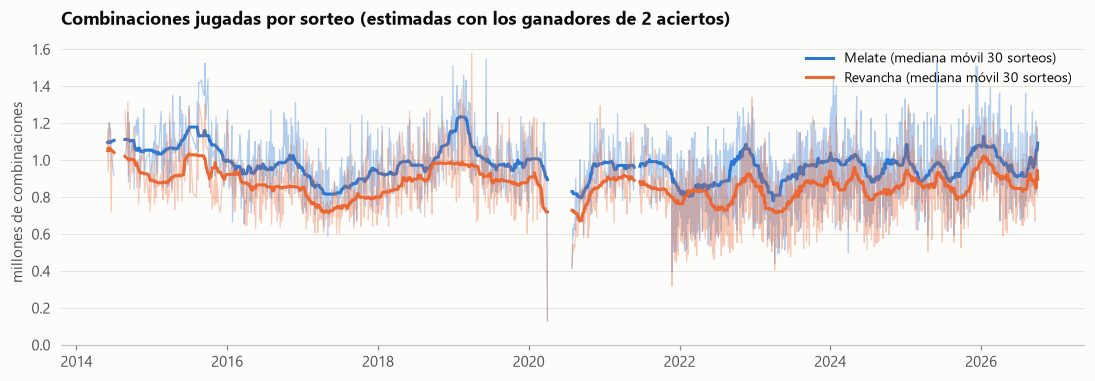

,count,mean,std,min,10%,50%,90%,max
juego,,,,,,,,
Melate,"1,435","959,951","178,878","129,620","725,203","964,852","1,188,630","1,548,550"
Revancha,"1,435","858,661","164,298","134,263","646,607","861,107","1,059,850","1,577,687"


In [8]:
g = datos.popularidad(pr)

fig, ax = plt.subplots(figsize=(12, 3.6))
for juego in ["Melate", "Revancha"]:
    s = g[g.juego == juego].set_index("fecha")["V"].sort_index()
    suave = s.rolling(30, center=True, min_periods=10).median()
    # Cortar las líneas donde faltan datos (> 3 semanas sin sorteos válidos)
    hueco = s.index.to_series().diff() > pd.Timedelta(days=21)
    s, suave = s.mask(hueco), suave.mask(hueco)
    ax.plot(s.index, s / 1e6, color=COLORES[juego], lw=0.8, alpha=0.35)
    ax.plot(suave.index, suave / 1e6, color=COLORES[juego], lw=2, label=f"{juego} (mediana móvil 30 sorteos)")
ax.set_ylabel("millones de combinaciones")
ax.set_title("Combinaciones jugadas por sorteo (estimadas con los ganadores de 2 aciertos)")
ax.set_ylim(0)
ax.legend(loc="upper right")
guardar(fig, "11_ventas_implicitas")
plt.show()
g.groupby("juego")["V"].describe(percentiles=[0.1, 0.5, 0.9]).map(lambda v: f"{v:,.0f}")

**Lectura:** se juegan alrededor de **1 millón de combinaciones por sorteo** en Melate y ~860 mil en Revancha (la Revancha es un complemento opcional del mismo boleto). Las caídas fuertes son reales: el concurso 3373 (01/04/2020) fue el último antes de la suspensión por la pandemia, y el siguiente se hizo hasta julio de 2020. Los sorteos del viernes, agregados en 2020, venden menos.

Esto también explica por qué la popularidad pesa poco en el **premio mayor**. Con ~1 millón de combinaciones jugadas y 32.5 millones posibles, el ganador del primer lugar rara vez lo comparte, salvo en combinaciones extremadamente populares.

## 4. ¿Hay señal de popularidad?
Para cada sorteo se calcula el **índice de popularidad** de la combinación ganadora con *k* aciertos:

`R_k = ganadores(k) / (V · P(k))`

Si todas las combinaciones se jugaran por igual, `R_k ≈ 1` y solo variaría por ruido de Poisson (≈ 1/√esperado). Hay dos pruebas de que la señal es real:
1. **Sobredispersión:** R varía mucho más de lo que permite el ruido de Poisson.
2. **Coherencia entre categorías:** el ruido de R₃ y el de R₄ son independientes. Si los dos están correlacionados, ambos miden lo mismo: qué tanto se jugaron *esos* números.

In [9]:
filas = []
for juego in ["Melate", "Revancha"]:
    x = g[g.juego == juego]
    for k_ in (3, 4, 5):
        ruido = np.sqrt(1 / x[f"E{k_}"]).median()
        filas.append({"juego": juego, "aciertos": k_, "ganadores esperados (mediana)": x[f"E{k_}"].median(),
                      "desv. est. de R observada": x[f"R{k_}"].std(), "desv. est. por puro ruido": ruido,
                      "sobredispersión (×)": x[f"R{k_}"].std() / ruido})
pd.DataFrame(filas).set_index(["juego", "aciertos"]).round(3)

ganadores esperados (mediana)  desv. est. de R observada  desv. est. por puro ruido  sobredispersión (×)
juego    aciertos                                                                                                          
Melate   3                             11648.908                      0.116                      0.009               12.487
         4                               546.043                      0.221                      0.043                5.161
         5                                 8.915                      0.564                      0.335                1.685
Revancha 3                             10396.369                      0.116                      0.010               11.783
         4                               487.330                      0.231                      0.045                5.101
         5                                 7.956                      0.705                      0.355                1.989

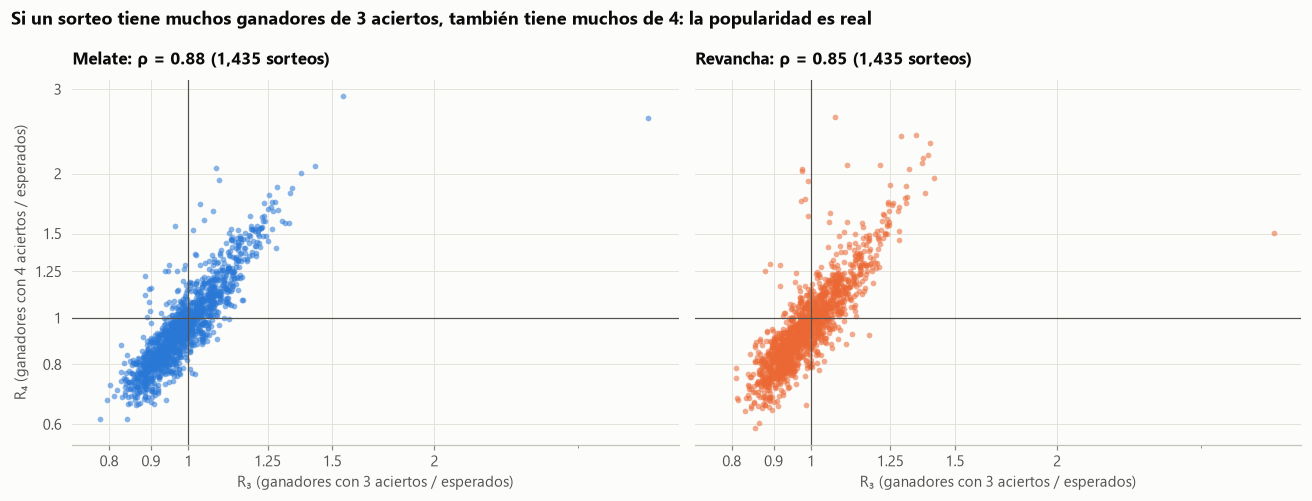

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, juego in zip(axes, ["Melate", "Revancha"]):
    x = g[g.juego == juego]
    ax.scatter(x.R3, x.R4, s=14, color=COLORES[juego], alpha=0.55, lw=0)
    ax.axhline(1, color=TEORICO, lw=0.8); ax.axvline(1, color=TEORICO, lw=0.8)
    rho, pv = stats.spearmanr(x.R3, x.R4)
    ax.set_title(f"{juego}: ρ = {rho:.2f} ({len(x):,} sorteos)", fontsize=11)
    ax.set_xlabel("R₃ (ganadores con 3 aciertos / esperados)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.grid(True, axis="both")
axes[0].set_ylabel("R₄ (ganadores con 4 aciertos / esperados)")
for ax in axes:
    for eje, marcas in ((ax.xaxis, [0.8, 0.9, 1, 1.25, 1.5, 2]), (ax.yaxis, [0.6, 0.8, 1, 1.25, 1.5, 2, 3])):
        eje.set_major_locator(mticker.FixedLocator(marcas))
        eje.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
        eje.set_minor_formatter(mticker.NullFormatter())
fig.suptitle("Si un sorteo tiene muchos ganadores de 3 aciertos, también tiene muchos de 4: la popularidad es real",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "12_popularidad_R3_vs_R4")
plt.show()

**Lectura:** con 3 aciertos, la popularidad varía **12 veces más** que el ruido de Poisson, y con 4 aciertos 5 veces más. En 5 aciertos (~9 ganadores esperados) el ruido domina y la señal casi no se distingue. En la gráfica, los sorteos con muchos ganadores de 3 aciertos también los tienen de 4 (ρ = 0.88 en Melate y 0.85 en Revancha). El ruido de las dos categorías es independiente, así que esa coincidencia solo puede venir de cuántas personas jugaron *esos* números.

**Alineación (4b):** en los cinco periodos la relación aparece solo con desfase 0 (ρ ≈ 0.46–0.55) y desaparece con los concursos vecinos (|ρ| ≤ 0.12). Las tablas válidas corresponden a su sorteo.

### 4b. ¿Cada tabla de premios corresponde a su sorteo?
Ya vimos que la fuente copió tablas entre concursos. También podría haberlas **desfasado** (publicar la tabla del concurso *k* en el *k+1*) sin que se note como duplicado. Para detectarlo, se relaciona la popularidad con un rasgo simple (cuántos números son ≤31) usando los números del mismo concurso y los de concursos vecinos. Si los datos están alineados, la relación solo aparece con desfase 0.

In [11]:
num = hist[["concurso", "juego", *N_COLS]]
def rho_desfase(g_, desfase):
    n_ = num.assign(concurso=num.concurso - desfase)  # números del concurso k+desfase
    m_ = g_.merge(n_, on=["concurso", "juego"])
    return stats.spearmanr((m_[N_COLS] <= 31).sum(axis=1), np.log(m_.R4.clip(lower=0.05)))[0]

g["periodo"] = pd.cut(g.fecha.dt.year, [2013, 2016, 2018, 2020, 2023, 2026], labels=["2014–16", "2017–18", "2019–20", "2021–23", "2024–26"])
alin = pd.DataFrame({f"desfase {s:+d}": [rho_desfase(g[g.periodo == p_], s) if (g.periodo == p_).sum() > 30 else np.nan
                                          for p_ in g.periodo.cat.categories] for s in (-2, -1, 0, 1, 2)},
                    index=g.periodo.cat.categories)
alin.insert(0, "sorteos (M+R)", g.groupby("periodo", observed=False).size())
alin.round(3)

,sorteos (M+R),desfase -2,desfase -1,desfase +0,desfase +1,desfase +2
2014–16,426,0.021,0.046,0.461,0.094,-0.029
2017–18,414,0.020,-0.075,0.533,-0.037,0.100
2019–20,354,0.036,-0.112,0.549,0.015,-0.015
2021–23,822,-0.002,-0.053,0.496,-0.018,-0.019
2024–26,854,-0.031,0.024,0.517,-0.051,-0.066


## 5. Primer vistazo: ¿qué hace popular a una combinación?
Se une cada sorteo con sus números ganadores y se compara la popularidad (R₄, que distingue mejor entre combinaciones) contra algunos rasgos candidatos. Esto todavía no es el modelo, solo una exploración para la fase siguiente.

In [12]:
d = g.merge(num, on=["concurso", "juego"], how="inner")
X = d[N_COLS].to_numpy()
d["≤31 (fechas)"] = (X <= 31).sum(axis=1)
d["≤12 (meses)"] = (X <= 12).sum(axis=1)
d["> 49"] = (X > 49).sum(axis=1)
d["múltiplos de 7"] = (X % 7 == 0).sum(axis=1)
d["consecutivos"] = (np.diff(X, axis=1) == 1).sum(axis=1)
d["misma terminación (máx)"] = [np.bincount(r % 10).max() for r in X]
d["logR4"] = np.log(d.R4.clip(lower=0.05))
d["logR3"] = np.log(d.R3)

rasgos = ["≤31 (fechas)", "≤12 (meses)", "> 49", "múltiplos de 7", "consecutivos", "misma terminación (máx)"]
corr = pd.DataFrame({f"ρ con log R{k_}": [stats.spearmanr(d[r], d[f"logR{k_}"])[0] for r in rasgos] for k_ in (3, 4)}, index=rasgos)
corr.round(3)

,ρ con log R3,ρ con log R4
≤31 (fechas),0.624,0.510
≤12 (meses),0.384,0.300
> 49,-0.304,-0.252
múltiplos de 7,0.026,0.029
consecutivos,-0.211,-0.246
misma terminación (máx),-0.042,-0.085


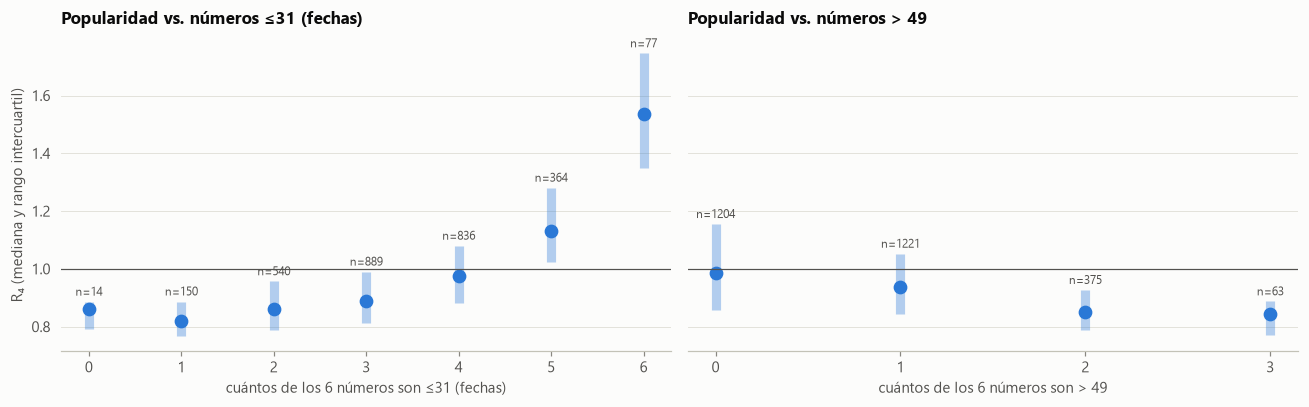

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, rasgo in zip(axes, ["≤31 (fechas)", "> 49"]):
    grp = d[d.groupby(rasgo)[rasgo].transform("size") >= 10].groupby(rasgo).R4  # solo grupos con ≥10 sorteos
    med = grp.median(); n = grp.size()
    q1, q3 = grp.quantile(0.25), grp.quantile(0.75)
    ax.vlines(med.index, q1, q3, color=COLORES["Melate"], lw=6, alpha=0.35)
    ax.plot(med.index, med.values, "o", color=COLORES["Melate"], ms=8)
    for x_, y_, n_ in zip(med.index, med.values, n.values):
        ax.annotate(f"n={n_}", (x_, q3[x_]), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8, color=TINTA_2)
    ax.axhline(1, color=TEORICO, lw=0.8)
    ax.set_xlabel(f"cuántos de los 6 números son {rasgo}")
    ax.set_xticks(med.index)
    ax.set_title(f"Popularidad vs. números {rasgo}", fontsize=11)
axes[0].set_ylabel("R₄ (mediana y rango intercuartil)")
fig.tight_layout()
guardar(fig, "13_popularidad_vs_rasgos")
plt.show()

In [14]:
cols = ["concurso", "juego", *N_COLS, "R3", "R4", 4, "E4"]
fmt = lambda t: t[cols].rename(columns={4: "ganadores 4", "E4": "esperados 4"}).round({"R3": 2, "R4": 2, "esperados 4": 0})
print("Combinaciones ganadoras MÁS jugadas (R₄ alto):")
display(fmt(d.nlargest(8, "R4")))
print("Combinaciones ganadoras MENOS jugadas (R₄ bajo):")
display(fmt(d.nsmallest(8, "R4")))

Combinaciones ganadoras MÁS jugadas (R₄ alto):


,concurso,juego,n1,n2,n3,n4,n5,n6,R3,R4,ganadores 4,esperados 4
434,3257,Melate,7,9,10,13,19,21,1.54,2.90,2397,827.0
2847,4251,Revancha,7,28,34,41,43,52,1.07,2.62,1330,508.0
1267,4105,Melate,19,27,33,41,42,50,3.65,2.61,1153,441.0
2350,3748,Revancha,6,9,12,18,23,30,1.34,2.41,919,382.0
1893,3281,Revancha,4,8,13,16,23,24,1.29,2.40,1463,611.0
1880,3268,Revancha,2,9,11,13,17,21,1.40,2.32,2070,893.0
1590,2974,Revancha,1,3,6,9,16,31,1.39,2.19,1329,607.0
1837,3223,Revancha,5,7,12,24,28,36,1.37,2.15,1425,662.0


Combinaciones ganadoras MENOS jugadas (R₄ bajo):


,concurso,juego,n1,n2,n3,n4,n5,n6,R3,R4,ganadores 4,esperados 4
2715,4118,Revancha,11,31,38,39,45,48,0.85,0.59,263,446.0
1636,3022,Revancha,2,4,30,36,41,47,0.86,0.60,312,518.0
1222,4058,Melate,2,26,29,35,36,45,0.84,0.61,348,567.0
712,3542,Melate,15,16,40,41,51,52,0.78,0.61,273,444.0
1739,3125,Revancha,17,27,30,40,51,55,0.83,0.64,245,383.0
2356,3754,Revancha,28,38,44,45,51,55,0.90,0.64,181,282.0
1935,3323,Revancha,29,32,36,37,41,46,0.84,0.65,258,397.0
2502,3902,Revancha,2,3,29,36,52,53,0.87,0.65,338,521.0


**Lectura (exploratoria, todavía sin modelo):**
- **Números ≤31 (fechas):** es el factor dominante (ρ = 0.62 con log R₃). La popularidad crece de forma monótona: con 0–3 números ≤31, R₄ ≈ 0.82–0.89; con 4, 0.97; con 5, 1.13; con los 6, **1.54**.
- **≤12 (meses):** suman popularidad, aunque en buena parte se traslapa con el efecto anterior.
- **Números >49:** restan popularidad. Casi nadie juega 50–56.
- **Consecutivos:** contra la intuición, las combinaciones ganadoras con consecutivos se jugaron *menos*. La gente tiende a "repartir" sus números.
- Las combinaciones ganadoras más jugadas son de números bajos y dispersos (7-9-10-13-19-21 tuvo 2.9 veces los ganadores esperados). Las menos jugadas son de números altos (31-35-39-41-50-51).

**Posibles rasgos para la fase 2:** posición en el boleto físico (filas, columnas, diagonales), números "de la suerte" (7, 13), coincidencia con combinaciones ganadoras recientes, y popularidad *por número individual* (un efecto por cada 1–56).

## 6. Conclusión y siguiente paso

1. **Los datos de premios son utilizables:** 1,435 concursos válidos (2014–2026), con los errores de la fuente identificados y descartados.
2. **La popularidad de una combinación es medible y predecible:** varía 5–12 veces más que el ruido, es consistente entre categorías y se explica en buena parte con rasgos simples de los números.
3. **Qué tan valioso es esto, en concreto:**
   - **2º a 5º lugar (premios que se reparten):** una combinación poco popular tiene ~0.8 veces los ganadores promedio y una muy popular ~1.5 veces o más. Al ganar, el premio individual puede ser **casi el doble** con una combinación impopular.
   - **3 y 2 aciertos:** son premios fijos ($43.01, $26.88, etc.), así que la popularidad no los afecta.
   - **Premio mayor:** casi nunca se comparte, así que la ganancia es pequeña salvo para evitar combinaciones *extremadamente* populares (secuencias, patrones, ganadoras anteriores), donde sí puede ser grande.
   - **Ninguna estrategia cambia la probabilidad de ganar, y el boleto sigue teniendo valor esperado negativo.** El modelo solo reduce cuánto se pierde en promedio.

### Fase 2 propuesta
- Modelo de **popularidad por combinación**: regresión robusta, e interpretable, de log R₃ y log R₄ con un efecto por número más rasgos de patrón. Se compara contra boosting y se valida con sorteos posteriores a los de entrenamiento.
- Con el modelo: calcular la **popularidad estimada de cualquier combinación** y el valor esperado de jugarla, y un generador de combinaciones de baja popularidad.